# Ultralytics YOLO11
- YOLO(You Only Look Once): 이미지나 비디오에서 객체를 실시간으로 탐지하는 딥러닝 모델 시리즈
- YOLOv4 까지는 C언어 기반의 Darknet 아키텍처가 사용되었지만, YOLOv5 부터는 Pytorch로 개발이 이루어짐
- 주요 특징
    - 향상된 성능: YOLOv8m 대비 22% 적은 매개변수로 더 높은 mAP(mean Average Precision)를 달성
    - 다양한 작업 지원: 객체 탐지, 인스턴스 분할, 이미지 분류, 자세 추정 등 다양한 컴퓨터 비전 작업을 지원
    - 효율성 및 속도 최적화: 정교한 아키텍처 설계와 최적화된 학습 파이프라인을 통해 처리 속도를 높이면서도 정확도를 유지
- pre-trained model, 학습데이터 정보인 yaml 파일만 바꾸어 주면 동일한 파이썬 API를 이용해서 다양한 작업을 할 수 있음
- https://docs.ultralytics.com/ko/models/yolo11/
- https://github.com/ultralytics/ultralytics



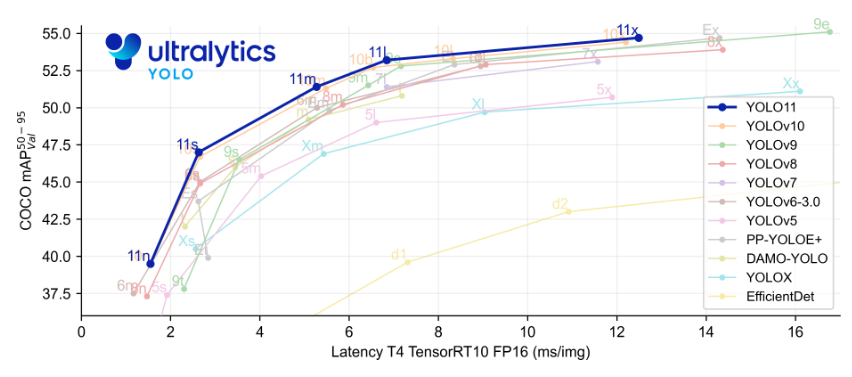

In [1]:
# 필수 라이브러리 설치
%pip install ultralytics

  Using cached ultralytics-8.4.51-py3-none-any.whl.metadata (36 kB)
  Using cached torchvision-0.27.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached polars-1.40.1-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.19-py3-none-any.whl.metadata (14 kB)
Using cached ultralytics-8.4.51-py3-none-any.whl (1.2 MB)
Using cached polars-1.40.1-py3-none-any.whl (828 kB)
Using cached torchvision-0.27.0-cp313-cp313-win_amd64.whl (4.1 MB)
Using cached ultralytics_thop-2.0.19-py3-none-any.whl (28 kB)

   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ---------------------------------------- 0/4 [polars]
   ------------------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# 라이브러리 로드
import torch
import ultralytics
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\playdata2\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
print(torch.__version__)
print(ultralytics.__version__)

2.12.0+cpu
8.4.51


- YOLO11 모델 다운로드 및 로드
    - MS COCO Dataset 사전학습된 yolo11n 모델을 로드함. yolo11n 외에도 yolo11s, yolo11m, yolo11l, yolo11x 등이 있음

In [7]:
model = YOLO('yolo11n.pt')

In [9]:
# 테스트 이미지 객체 탐지 수행
# http://ultralytics.com/images/zidane.jpg

result1 = model('http://ultralytics.com/images/zidane.jpg')

result1[0].show()


image 1/1 c:\Users\playdata2\workspace\deep_learning\zidane.jpg: 384x640 2 persons, 1 tie, 393.2ms
Speed: 9.8ms preprocess, 393.2ms inference, 3.5ms postprocess per image at shape (1, 3, 384, 640)


In [10]:
# 테스트 이미지 객체 탐지 수행
# http://ultralytics.com/images/bus.jpg

result2 = model('http://ultralytics.com/images/bus.jpg')

result2[0].show()


image 1/1 c:\Users\playdata2\workspace\deep_learning\bus.jpg: 640x480 4 persons, 1 bus, 897.9ms
Speed: 126.2ms preprocess, 897.9ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 480)


- YOLO11은 MS COCO 데이터로 사전학습되어 있기 때문에, model.names를 통해서 확인해보면 총 80개의 클래스가 있다는 것을 알 수 있다.(총 80개, 0~79)

In [11]:
print(type(model.names), len(model.names))

print(model.names)

<class 'dict'> 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell p

In [15]:
result3 = model('data/test1.jpg')

result3[0].show()


image 1/1 c:\Users\playdata2\workspace\deep_learning\data\test1.jpg: 544x640 1 laptop, 1 mouse, 1 keyboard, 1 cell phone, 1355.6ms
Speed: 41.8ms preprocess, 1355.6ms inference, 1.9ms postprocess per image at shape (1, 3, 544, 640)


In [16]:
for i in range(1,8):
    model(source=f'data/test{i}.jpg', save=True)


image 1/1 c:\Users\playdata2\workspace\deep_learning\data\test1.jpg: 544x640 1 laptop, 1 mouse, 1 keyboard, 1 cell phone, 229.5ms
Speed: 3.8ms preprocess, 229.5ms inference, 1.8ms postprocess per image at shape (1, 3, 544, 640)
Results saved to C:\Users\playdata2\workspace\deep_learning\runs\detect\predict

image 1/1 c:\Users\playdata2\workspace\deep_learning\data\test2.jpg: 448x640 4 zebras, 1 giraffe, 152.4ms
Speed: 3.3ms preprocess, 152.4ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\playdata2\workspace\deep_learning\runs\detect\predict

image 1/1 c:\Users\playdata2\workspace\deep_learning\data\test3.jpg: 640x640 2 cups, 1 bowl, 2 sandwichs, 1 dining table, 321.9ms
Speed: 6.1ms preprocess, 321.9ms inference, 14.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\playdata2\workspace\deep_learning\runs\detect\predict

image 1/1 c:\Users\playdata2\workspace\deep_learning\data\test4.jpg: 480x640 2 persons, 1 truck